<a href="https://colab.research.google.com/github/admmuaka/admmuaka.github.io/blob/main/SpeechCommand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installons les dépendances nécessaires

In [ ]:
# GPU:
!pip install pydub torch==1.7.0+cu101 torchvision==0.8.1+cu101 torchaudio==0.7.0 -f https://download.pytorch.org/whl/torch_stable.html

Looking in links: https://download.pytorch.org/whl/torch_stable.html
  Using cached pydub-0.25.1-py2.py3-none-any.whl.metadata (1.4 kB)
ERROR: Could not find a version that satisfies the requirement torch==1.7.0+cu101 (from versions: 1.11.0, 1.11.0+cpu, 1.11.0+cu102, 1.11.0+cu113, 1.11.0+cu115, 1.11.0+rocm4.3.1, 1.11.0+rocm4.5.2, 1.12.0, 1.12.0+cpu, 1.12.0+cu102, 1.12.0+cu113, 1.12.0+cu116, 1.12.0+rocm5.0, 1.12.0+rocm5.1.1, 1.12.1, 1.12.1+cpu, 1.12.1+cu102, 1.12.1+cu113, 1.12.1+cu116, 1.12.1+rocm5.0, 1.12.1+rocm5.1.1, 1.13.0, 1.13.0+cpu, 1.13.0+cu116, 1.13.0+cu117, 1.13.0+cu117.with.pypi.cudnn, 1.13.0+rocm5.1.1, 1.13.0+rocm5.2, 1.13.1, 1.13.1+cpu, 1.13.1+cu116, 1.13.1+cu117, 1.13.1+cu117.with.pypi.cudnn, 1.13.1+rocm5.1.1, 1.13.1+rocm5.2, 2.0.0, 2.0.0+cpu, 2.0.0+cpu.cxx11.abi, 2.0.0+cu117, 2.0.0+cu117.with.pypi.cudnn, 2.0.0+cu118, 2.0.0+rocm5.3, 2.0.0+rocm5.4.2, 2.0.1, 2.0.1+cpu, 2.0.1+cpu.cxx11.abi, 2.0.1+cu117, 2.0.1+cu117.with.pypi.cudnn, 2.0.1+cu118, 2.0.1+rocm5.3, 2.0.1+rocm5.4.2, 

# Les bibliothèques

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
import sys

import matplotlib.pyplot as plt
import IPython.display as ipd

from tqdm import tqdm

import torchaudio.transforms as transforms
from torch.optim.lr_scheduler import StepLR

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Importation du jeu de données

Nous utilisons torchaudio pour télécharger et représenter le jeu de données. Ici, nous utilisons
[SpeechCommands](https://arxiv.org/abs/1804.03209)_, un ensemble de données contenant 35 commandes vocales prononcées par différentes personnes. Ce jeu de données, SPEECHCOMMANDS, est une version adaptée en torch.utils.data.Dataset. Dans cet ensemble, tous les fichiers audio durent environ 1 seconde (soit environ 16 000 trames temporelles).

Le chargement et la mise en forme des données se font au moment où un point de données est accédé. Torchaudio s'occupe de convertir les fichiers audio en tenseurs. Si vous souhaitez charger un fichier audio directement, vous pouvez utiliser torchaudio.load(). Cette fonction retourne un tuple contenant le tenseur créé ainsi que la fréquence d'échantillonnage du fichier audio (16 kHz pour SpeechCommands).

Revenons au jeu de données : ici, nous créons une sous-classe qui le divise en sous-ensembles standards pour l'entraînement, la validation et le test.



In [ ]:
from torchaudio.datasets import SPEECHCOMMANDS
import os


class SubsetSC(SPEECHCOMMANDS):
    def __init__(self, subset: str = None):
        super().__init__("./", download=True)

        def load_list(filename):
            filepath = os.path.join(self._path, filename)
            with open(filepath) as fileobj:
                return [os.path.normpath(os.path.join(self._path, line.strip())) for line in fileobj]

        if subset == "validation":
            self._walker = load_list("validation_list.txt")
        elif subset == "testing":
            self._walker = load_list("testing_list.txt")
        elif subset == "training":
            excludes = load_list("validation_list.txt") + load_list("testing_list.txt")
            excludes = set(excludes)
            self._walker = [w for w in self._walker if w not in excludes]
            #Exclut les fichiers des ensembles de validation et de test pour garantir
            # que l’entraînement utilise des données distinctes.


# Create training and testing split of the data. We do not use validation in this tutorial.
train_set = SubsetSC("training")
test_set = SubsetSC("testing")

**Paramètres et leur rôle**

**subset :**Définit le sous-ensemble du dataset à charger (training, validation, ou testing).

**load_list(filename) :**Permet de charger dynamiquement les chemins des fichiers audio depuis les fichiers texte fournis avec le dataset.

**self._walker :**
Liste des chemins des fichiers audio à inclure dans l'ensemble spécifié.


In [ ]:
waveform, sample_rate, label, speaker_id, utterance_number = train_set[0]
print("Shape of waveform: {}".format(waveform.size())) #Renvoie la taille du tensor représentant le signal audio.
print("Sample rate of waveform: {}".format(sample_rate)) #Affiche la fréquence d’échantillonnage du signal audio

Shape of waveform: torch.Size([1, 16000])
Sample rate of waveform: 16000


- Obtenir les étiquettes uniques

In [ ]:
labels = sorted(list(set(datapoint[2] for datapoint in train_set)))
labels

['backward',
 'bed',
 'bird',
 'cat',
 'dog',
 'down',
 'eight',
 'five',
 'follow',
 'forward',
 'four',
 'go',
 'happy',
 'house',
 'learn',
 'left',
 'marvin',
 'nine',
 'no',
 'off',
 'on',
 'one',
 'right',
 'seven',
 'sheila',
 'six',
 'stop',
 'three',
 'tree',
 'two',
 'up',
 'visual',
 'wow',
 'yes',
 'zero']

La liste contient **35 étiquettes uniques**, qui représentent les **commandes vocales** dans le dataset **SpeechCommands**. Chaque étiquette correspond à une classe cible pour la tâche de classification audio.


**Structure et contenu des étiquettes**

Les étiquettes sont des mots simples, qui peuvent être regroupés en différentes catégories:

* **Commandes directionnelles :**

"backward", "forward", "left", "right", "up", "down".

* **Commandes d'état**:

"on", "off", "stop", "go" .

* **Réponses binaires :**

"yes", "no".

* **Nombres :**

"zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine".

* **Noms propres :**

"marvin", "sheila".

**Autres :**

"bed", "bird", "cat", "dog", "happy", "house", "tree", "visual", "wow", "learn", "follow".












- Définir les fonctions utilitaires

In [ ]:
def label_to_index(word):
    # Retourne la position du mot dans les étiquettes
    return torch.tensor(labels.index(word))


def index_to_label(index):
    # Retourne le mot correspondant à l'indice dans les étiquettes
    # Ceci est l'inverse de label_to_index
    return labels[index]


word_start = "yes"
index = label_to_index(word_start)
word_recovered = index_to_label(index)

print(word_start, "-->", index, "-->", word_recovered)

yes --> tensor(33) --> yes


- Définir la transformation en  Melspectrogramme pour le jeu de données


In [ ]:
# MelSpectrogram transformation
mel_transform = transforms.MelSpectrogram(
    sample_rate=16000,
    n_fft=1024,
    hop_length=512,
    n_mels=128
)

### Explication de la transformation MelSpectrogram

La transformation MelSpectrogram est une étape clé dans le traitement des signaux audio pour des tâches comme la reconnaissance vocale ou la classification musicale. Elle convertit les formes d'onde audio brutes en un spectrogramme basé sur l'échelle de Mel, qui correspond mieux à la perception humaine du son.

#### Parameters
1. **`sample_rate=16000`**
   
   - Spécifie la fréquence d'échantillonnage audio, c'est-à-dire le nombre d'échantillons par seconde.
   - Une fréquence d'échantillonnage de 16 kHz est courante pour le traitement de la parole, car elle capture l'essentiel de la gamme de fréquences de la voix humaine jusqu'à 8 kHz, selon le théorème de Nyquist(Le théorème de Nyquist-Shannon stipule que pour reproduire un signal sans perte d'information, il faut l'échantillonner à une fréquence au moins deux fois supérieure à la fréquence maximale du signal,la voix humaine typique se situe dans une plage de fréquences allant de 85 Hz à environ 8 kHz.
Échantillonner à une fréquence de 16 kHz (2 X 8 kHz) garantit que l'ensemble des fréquences vocales pertinentes est capturé sans perte).

2. **`n_fft=1024`**

   - Définit la taille de la fenêtre pour la Transformée de Fourier Rapide (FFT).
   - Une valeur de 1024 signifie que chaque fenêtre utilisée pour le calcul de la FFT contiendra 1024 échantillons.
   - Cela influence la résolution fréquentielle du spectrogramme :
      - Grand n_fft : Résolution fréquentielle élevée, mais moins de précision temporelle.
      - Petit n_fft : Résolution temporelle élevée, mais moins de précision fréquentielle.

3. **`hop_length=512`**

   - Le nombre d'échantillons audio entre deux trames consécutives du spectrogramme.
   - Contrôle le chevauchement entre les trames adjacentes. Une valeur de 512 (chevauchement de 50 % pour une FFT de 1024 points) offre un bon équilibre entre la résolution temporelle et fréquentielle.


4. **`n_mels=128`**

   - Le nombre de bandes de Mel (ou filtres) utilisées pour projeter l'axe des fréquences sur l'échelle de Mel.
   - Une valeur de 128 est typique, capturant suffisamment d'informations fréquentielles pour la plupart des tâches sans coût computationnel excessif.

#### Objectif de la transformation
1. **Représentation temps-fréquence**
   - Convertir le signal audio brut (forme d'onde 1D) en une représentation 2D où :
     - L'axe des x représente le temps.
     - L'axe des y représente les bandes de fréquences sur l'échelle de Mel.


2. **Échelle de Mel**
  
   - Imite la perception auditive humaine en utilisant un espacement non linéaire des bandes de fréquences, en mettant l'accent sur les basses fréquences et en compressant les fréquences élevées.
   - Cela la rend plus adaptée aux tâches nécessitant une interprétation semblable à celle des humains.

3. **Prétraitement pour les réseaux neuronaux**
   
   - Les réseaux neuronaux performent souvent mieux avec des entrées 2D comme les spectrogrammes, permettant une extraction de caractéristiques spatiales à l'aide de couches convolutionnelles.


#### Application
Cette transformation est largement utilisée dans :
- **Reconnaissance vocale :**Extraction des caractéristiques des données vocales.
- **Analyse musicale:** Classification des genres musicaux ou identification des instruments.
- **Classification des sons environnementaux:** Détection de sons tels que des pas, des alarmes ou des chants d'oiseaux.


En utilisant la transformation `MelSpectrogram`, l'audio brut est converti dans un format qui conserve les informations cruciales de fréquence et de temporalité tout en s'alignant sur la perception auditive humaine.




- **On va appliquer le padding et définir le DataLoader**

Les fichiers audio ayant des durées différentes, leurs spectrogrammes ont également des tailles temporelles variables.
On applique un padding (remplissage) pour que toutes les séquences dans un lot aient la même longueur.

In [ ]:
def pad_sequence(batch):
    # Pour remplir tous les tenseurs dans le lot pour qu'ils aient la même longueur
    batch = torch.nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=0.0)
    return batch

def collate_fn(batch):
    # Un tuple de données a la forme suivante :
    # waveform, sample_rate, label, speaker_id, utterance_number

    tensors, targets = [], []

    # On assemble dans des listes et encode les étiquettes en tant qu'indices
    for waveform, _, label, *_ in batch:
        # On supprime la dimension du canal si elle est égale à 1 (par exemple, [1, 16000] -> [16000])
        waveform = waveform.squeeze(0)
        # On applique la transformation MelSpectrogram
        mel_spectrogram = mel_transform(waveform)
        tensors.append(mel_spectrogram.T)  # Transposer pour obtenir (Temps, Fréquence-Mel)
        targets.append(label_to_index(label))

    # On regroupe la liste de tenseurs en un tenseur par lot
    tensors = pad_sequence(tensors)
    targets = torch.tensor(targets)

    return tensors, targets

batch_size = 256

if device == "cuda":
    num_workers = 1 # Nombre de sous-processus pour charger les données.
    pin_memory = True
else:
    num_workers = 0
    pin_memory = False

# On charge les données d'entraînement
train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True, #Mélange les données pour améliorer la généralisation.
    collate_fn=collate_fn, #Utilise la fonction de regroupement pour normaliser les lots.
    num_workers=num_workers,
    pin_memory=pin_memory,
)
#Charge les données de test.
test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False, #Garde le dernier lot même s'il est plus petit que batch_size.
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

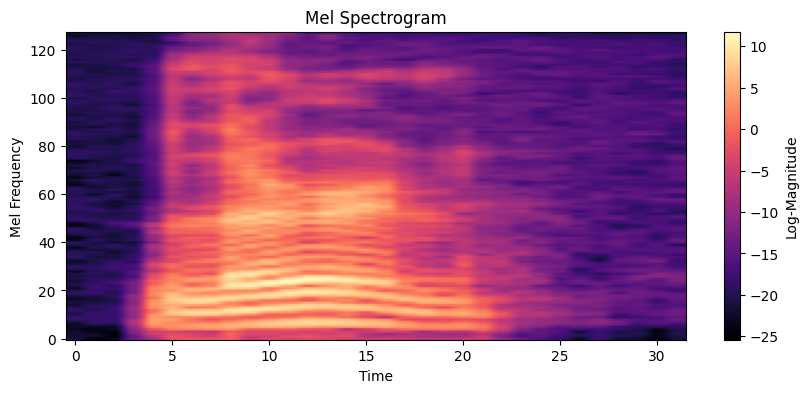

In [ ]:
# Affichage un  Melspectrogram
def show_mel_spectrogram(data_loader):
    for batch in data_loader:
        tensors, _ = batch
        mel_spectrogram = tensors[0].cpu()  # On prend le premier exemple du lot
        plt.figure(figsize=(10, 4))
        plt.imshow(mel_spectrogram.T.log2(), aspect="auto", origin="lower", cmap="magma")
        plt.colorbar(label="Log-Magnitude")
        plt.title("Mel Spectrogram")
        plt.xlabel("Time")
        plt.ylabel("Mel Frequency")
        plt.show()
        break

# On affiche un  Melspectrogram issu du jeu d'entraînement
show_mel_spectrogram(train_loader)

- Zones lumineuses (jaunes/oranges) :
  - Correspondent aux fréquences dominantes dans le signal.
  - Représentent souvent des phonèmes ou des sons vocaux prononcés.

- Zones sombres (violettes) :
  - Correspondent aux fréquences de faible intensité ou à des silences dans le signal.


- Définition du réseau

In [ ]:
class M5_2D(nn.Module):
    def __init__(self, n_input=1, n_output=35, n_channel=64):
        super().__init__()
        self.conv1 = nn.Conv2d(n_input, n_channel, kernel_size=(3, 3), padding=(1, 1))
        self.bn1 = nn.BatchNorm2d(n_channel)
        self.conv2 = nn.Conv2d(n_channel, n_channel, kernel_size=(3, 3), padding=(1, 1))
        self.bn2 = nn.BatchNorm2d(n_channel)
        self.pool1 = nn.MaxPool2d((2, 2))

        self.conv3 = nn.Conv2d(n_channel, 2 * n_channel, kernel_size=(3, 3), padding=(1, 1))
        self.bn3 = nn.BatchNorm2d(2 * n_channel)
        self.conv4 = nn.Conv2d(2 * n_channel, 2 * n_channel, kernel_size=(3, 3), padding=(1, 1))
        self.bn4 = nn.BatchNorm2d(2 * n_channel)
        self.pool2 = nn.MaxPool2d((2, 2))

        self.conv5 = nn.Conv2d(2 * n_channel, 4 * n_channel, kernel_size=(3, 3), padding=(1, 1))
        self.bn5 = nn.BatchNorm2d(4 * n_channel)
        self.conv6 = nn.Conv2d(4 * n_channel, 4 * n_channel, kernel_size=(3, 3), padding=(1, 1))
        self.bn6 = nn.BatchNorm2d(4 * n_channel)
        self.pool3 = nn.AdaptiveAvgPool2d((1, 1))

        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(4 * n_channel, n_output)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)

        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)

        x = x.view(x.size(0), -1)  # Flatten
        x = self.dropout(x)
        x = self.fc1(x)
        return F.log_softmax(x, dim=1)

# En supposant que transformed.shape = (batch_size, 1, time, mel_frequency)
n_input = 1  # Nombre de canaux d'entrée(1 pour un Melspectrogramme  à un seul canal)
n_output = len(labels)  # Nombre de classes
n_channel = 32  # Nombre de canaux de base

model = M5_2D(n_input=n_input, n_output=n_output, n_channel=n_channel)
model.to(device)
print(model)

# On compte les paramètres

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

n = count_parameters(model)
print("Number of parameters: %s" % n) #Nombre de paramètres

M5_2D(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=Tr

### Pourquoi le modèle M5_2D est meilleur que le modèle M5 pour les données 1D

#### 1. **Utilisation des convolutions 2D**
   - **`M5_2D`** utilise `nn.Conv2d`, qui est conçu pour traiter des entrées 2D, comme les spectrogrammes (temps vs fréquence). Cela correspond mieux aux spectrogrammes Mel, qui sont naturellement en deux dimensions (temps et fréquence).
   - **`M5`** utilise `nn.Conv1d`, qui est mieux adapté aux signaux 1D, comme les formes d'onde audio brutes ou les séquences, mais n'exploite pas pleinement la structure 2D des données de spectrogramme.

#### 2. **Représentation des caractéristiques**
   - **`M5_2D`** utilise plusieurs couches de convolution avec des opérations 2D qui capturent mieux les motifs locaux à la fois dans les domaines temporel et fréquentiel, ce qui permet une extraction de caractéristiques plus riche.
   - **`M5`** est limité aux convolutions 1D, qui capturent principalement les caractéristiques dans une seule dimension (temps) et peuvent ne pas apprendre efficacement les interactions temps-fréquence.

#### 3. **Efficacité des paramètres**
   - **`M5_2D`** commence avec un nombre réduit de canaux de base (n_channel=32 dans l'exemple) et augmente progressivement le nombre de filtres à mesure que la carte de caractéristiques est sous-échantillonnée, équilibrant ainsi l'efficacité des paramètres et la puissance d'expression.
   - **`M5`** commence avec moins de canaux mais ne profite pas des avantages des cartes de caractéristiques 2D, ce qui peut nécessiter des architectures plus complexes pour atteindre les mêmes performances.

#### 4. **Stratégie de pooling**
   - **`M5_2D`**  combine `MaxPool2d` and `AdaptiveAvgPool2d` pour réduire progressivement la taille des cartes de caractéristiques tout en conservant les caractéristiques globales significatives, garantissant que le réseau est robuste aux variations de taille d'entrée.

   - **`M5`**  utilise `MaxPool1d` et un pooling moyen dans la couche finale, ce qui peut ne pas capturer autant de contexte global aussi efficacement que le pooling adaptatif de la version 2D.

#### 5. **Dropout pour la régularisation**
   - **`M5_2D`** inclut une couche  `Dropout` après l'aplatissement pour réduire le surapprentissage, ce qui est particulièrement important pour les modèles avec un grand nombre de paramètres.
   - **`M5`** ne comprend pas de dropout explicite, ce qui pourrait conduire à un surapprentissage dans certains cas.

#### 6. **Meilleure évolutivité et flexibilité**
   - **`M5_2D`** peut s'adapter plus naturellement aux tâches nécessitant une analyse détaillée des spectrogrammes, comme la reconnaissance vocale ou la classification de genres musicaux, grâce à son architecture 2D.
   - **`M5`** peut avoir du mal à généraliser sur des tâches nécessitant une compréhension des motifs dans deux dimensions..

#### 7. **Compatibilité de sortie**
   - Les deux modèles se terminent par une couche entièrement connectée, mais **`M5_2D`** aplatit directement sa sortie poolée de manière adaptative, simplifiant l'architecture et assurant une robustesse face à des tailles d'entrée variables.

#### 8. **Nombre de paramètres**
   - Le nombre de paramètres pour les deux modèles peut influencer le temps d'entraînement et l'utilisation de la mémoire. Bien que **`M5_2D`** puisse avoir un nombre de paramètres légèrement plus élevé, il justifie cela par une amélioration significative de l'extraction des caractéristiques et des performances sur les données 2D.


### Conclusion
Le modèle **`M5_2D`** est mieux adapté aux entrées de type spectrogramme Mel grâce à sa capacité à exploiter les convolutions 2D, son extraction avancée des caractéristiques et ses stratégies de pooling efficaces. Il offre une plus grande flexibilité et de meilleures performances, en particulier pour les tâches de traitement audio basées sur des spectrogrammes.

### Couches et progression des dimensions

| **Bloc**          | **Type**                 | **Entrée → Sortie (Dimensions)**                     |
|--------------------|--------------------------|-----------------------------------------------------|
| **Bloc 1**         | Conv2D + BatchNorm       | $(1, T, F) \rightarrow (32, T, F)$                 |
|                    | MaxPool2D               | $(32, T, F) \rightarrow (32, T/2, F/2)$            |
| **Bloc 2**         | Conv2D + BatchNorm       | $(32, T/2, F/2) \rightarrow (64, T/2, F/2)$        |
|                    | MaxPool2D               | $(64, T/2, F/2) \rightarrow (64, T/4, F/4)$        |
| **Bloc 3**         | Conv2D + BatchNorm       | $(64, T/4, F/4) \rightarrow (128, T/4, F/4)$       |
|                    | AdaptiveAvgPool2D       | $(128, T/4, F/4) \rightarrow (128, 1, 1)$          |
| **Fully Connected**| Dropout + Linear         | $(128) \rightarrow (35)$ *(nombre de classes)*      |



### On définie l'optimiseur et le planificateur

- Un optimiseur : Utilisé pour mettre à jour les poids du modèle en minimisant la fonction de perte.

- Un scheduler (planificateur) : Ajuste le taux d'apprentissage (learning rate) pendant l'entraînement.
Ces choix sont cruciaux pour l'entraînement efficace et la convergence du modèle.

In [ ]:
# from torch.optim.lr_scheduler import ReduceLROnPlateau
# Optimiseur et planificateur du taux d'apprentissage
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)  # réduire le taux d'apprentissage après 20 époques par un facteur de 10


- On entraîne le réseau

In [ ]:
def train(model, epoch, log_interval):
    model.train()
    epoch_loss = 0  # Pour suivre la perte pendant toute l'époque
    for batch_idx, (data, target) in enumerate(train_loader):
        # Pour déplacer les données et les cibles sur le périphérique
        data = data.to(device)
        target = target.to(device)

        # Pour ajouter une dimension de canal si les données ont 3 dimensions
        if data.dim() == 3:
            data = data.unsqueeze(1)  # [batch_size, time, mel_frequency] -> [batch_size, 1, time, mel_frequency]

        # Permuter les dimensions pour correspondre aux exigences de Conv2d
        data = data.permute(0, 1, 3, 2)  # [batch_size, time, mel_frequency] -> [batch_size, 1, time, mel_frequency]

        # Passe avant
        output = model(data)

        # Calculer la perte
        loss = F.nll_loss(output, target)

        # Rétropropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Ajouter la perte de l'époque
        epoch_loss += loss.item()

       # Afficher les statistiques d'entraînement
        if batch_idx % log_interval == 0:
            print(
                f"Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} "
                f"({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}"
            )
   # Afficher la perte moyenne pour l'époque
    print(f"Epoch {epoch} - Average Loss: {epoch_loss / len(train_loader):.6f}")

# Mettre à jour le planificateur après chaque époque
def adjust_learning_rate(scheduler):
    scheduler.step()
    print(f"Adjusted learning rate: {scheduler.get_last_lr()[0]}") #Taux d'apprentissage ajusté

In [ ]:
def number_of_correct(pred, target):
    # On compte le nombre de prédictions correctes
    return pred.eq(target).sum().item()


def get_likely_index(tensor):
    # On trouve l'indice de l'étiquette la plus probable pour chaque élément du lot
    return tensor.argmax(dim=-1)


def test(model, epoch):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            # On déplace les données et les cibles sur le périphérique
            data = data.to(device)
            target = target.to(device)

            # On ajoute une dimension de canal si les données ont 3 dimensions
            if data.dim() == 3:
                data = data.unsqueeze(1)  # [batch_size, time, mel_frequency] -> [batch_size, 1, time, mel_frequency]

            # On permute les dimensions pour correspondre aux exigences de Conv2d
            data = data.permute(0, 1, 3, 2)  # [batch_size, 1, time, mel_frequency] -> [batch_size, 1, mel_frequency, time]

            # Forward pass
            output = model(data)

            # Pour bbtenir les prédictions
            pred = get_likely_index(output)
            correct += number_of_correct(pred, target)

    # On Calcule et affiche la précision
    accuracy = 100. * correct / len(test_loader.dataset)
    print(f"\nTest Epoch: {epoch}\tAccuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n")
    return accuracy



In [ ]:
from tqdm import tqdm

# Boucle d'entraînement et de test
log_interval = 20
n_epoch = 10

# Mettre à jour la taille de pas de la barre de progression
pbar_update = 1 / (len(train_loader) + len(test_loader))
losses = []
best_accuracy = 0
# Boucle d'entraînement
with tqdm(total=n_epoch, desc="Training Progress", unit="epoch") as pbar:
    for epoch in range(1, n_epoch + 1):
        print(f"\nEpoch {epoch}/{n_epoch}")
        train(model, epoch, log_interval)  # Entraînement pour une époque
        accuracy = test(model, epoch)  # Évaluation sur l'ensemble de test
        scheduler.step()   # Ajuster le taux d'apprentissage
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            torch.save(model.state_dict(), "best_model.pth")
            print(f"New best model saved with accuracy: {best_accuracy:.2f}%")
        # Mettre à jour la barre de progression
        pbar.update(1)

print("Training and testing completed.")




Training Progress:   0%|          | 0/10 [00:00<?, ?epoch/s]


Epoch 1/10
Train Epoch: 1 [0/84843 (0%)]	Loss: 3.562014
Train Epoch: 1 [5120/84843 (6%)]	Loss: 3.484045
Train Epoch: 1 [10240/84843 (12%)]	Loss: 3.509973
Train Epoch: 1 [15360/84843 (18%)]	Loss: 3.523049
Train Epoch: 1 [20480/84843 (24%)]	Loss: 3.374624
Train Epoch: 1 [25600/84843 (30%)]	Loss: 3.284286
Train Epoch: 1 [30720/84843 (36%)]	Loss: 3.215881
Train Epoch: 1 [35840/84843 (42%)]	Loss: 3.046231
Train Epoch: 1 [40960/84843 (48%)]	Loss: 3.200947
Train Epoch: 1 [46080/84843 (54%)]	Loss: 3.078707
Train Epoch: 1 [51200/84843 (60%)]	Loss: 2.980498
Train Epoch: 1 [56320/84843 (66%)]	Loss: 2.878750
Train Epoch: 1 [61440/84843 (72%)]	Loss: 2.688281
Train Epoch: 1 [66560/84843 (78%)]	Loss: 2.661912
Train Epoch: 1 [71680/84843 (84%)]	Loss: 2.559842
Train Epoch: 1 [76800/84843 (90%)]	Loss: 2.284599
Train Epoch: 1 [81920/84843 (96%)]	Loss: 2.215347
Epoch 1 - Average Loss: 3.019811


Training Progress:  10%|█         | 1/10 [07:30<1:07:38, 450.96s/epoch]


Test Epoch: 1	Accuracy: 582/11005 (5.29%)

New best model saved with accuracy: 5.29%

Epoch 2/10
Train Epoch: 2 [0/84843 (0%)]	Loss: 2.141897
Train Epoch: 2 [5120/84843 (6%)]	Loss: 2.067899
Train Epoch: 2 [10240/84843 (12%)]	Loss: 1.921383
Train Epoch: 2 [15360/84843 (18%)]	Loss: 1.789448
Train Epoch: 2 [20480/84843 (24%)]	Loss: 1.781651
Train Epoch: 2 [25600/84843 (30%)]	Loss: 1.660264
Train Epoch: 2 [30720/84843 (36%)]	Loss: 1.599650
Train Epoch: 2 [35840/84843 (42%)]	Loss: 1.439129
Train Epoch: 2 [40960/84843 (48%)]	Loss: 1.243561
Train Epoch: 2 [46080/84843 (54%)]	Loss: 1.275275
Train Epoch: 2 [51200/84843 (60%)]	Loss: 1.425027
Train Epoch: 2 [56320/84843 (66%)]	Loss: 1.662996
Train Epoch: 2 [61440/84843 (72%)]	Loss: 1.295274
Train Epoch: 2 [66560/84843 (78%)]	Loss: 1.164708
Train Epoch: 2 [71680/84843 (84%)]	Loss: 1.364936
Train Epoch: 2 [76800/84843 (90%)]	Loss: 1.251853
Train Epoch: 2 [81920/84843 (96%)]	Loss: 1.104423
Epoch 2 - Average Loss: 1.459812


Training Progress:  20%|██        | 2/10 [15:00<1:00:00, 450.01s/epoch]

...


Test Epoch: 8	Accuracy: 403/11005 (3.66%)


Epoch 9/10
Train Epoch: 9 [0/84843 (0%)]	Loss: 0.743010
Train Epoch: 9 [5120/84843 (6%)]	Loss: 0.687560
Train Epoch: 9 [10240/84843 (12%)]	Loss: 0.639577
Train Epoch: 9 [15360/84843 (18%)]	Loss: 0.798592
Train Epoch: 9 [20480/84843 (24%)]	Loss: 0.622942
Train Epoch: 9 [25600/84843 (30%)]	Loss: 0.633340
Train Epoch: 9 [30720/84843 (36%)]	Loss: 0.742922
Train Epoch: 9 [35840/84843 (42%)]	Loss: 0.771908
Train Epoch: 9 [40960/84843 (48%)]	Loss: 0.650173
Train Epoch: 9 [46080/84843 (54%)]	Loss: 0.737758
Train Epoch: 9 [51200/84843 (60%)]	Loss: 0.608323
Train Epoch: 9 [56320/84843 (66%)]	Loss: 0.666212
Train Epoch: 9 [61440/84843 (72%)]	Loss: 0.654372
Train Epoch: 9 [66560/84843 (78%)]	Loss: 0.776746
Train Epoch: 9 [71680/84843 (84%)]	Loss: 0.698198
Train Epoch: 9 [76800/84843 (90%)]	Loss: 0.766459
Train Epoch: 9 [81920/84843 (96%)]	Loss: 0.675813
Epoch 9 - Average Loss: 0.686744


Training Progress:  90%|█████████ | 9/10 [1:07:18<07:27, 447.59s/epoch]


Test Epoch: 9	Accuracy: 5814/11005 (52.83%)


Epoch 10/10
Train Epoch: 10 [0/84843 (0%)]	Loss: 0.677429
Train Epoch: 10 [5120/84843 (6%)]	Loss: 0.650328
Train Epoch: 10 [10240/84843 (12%)]	Loss: 0.672402
Train Epoch: 10 [15360/84843 (18%)]	Loss: 0.675527
Train Epoch: 10 [20480/84843 (24%)]	Loss: 0.680409
Train Epoch: 10 [25600/84843 (30%)]	Loss: 0.592927
Train Epoch: 10 [30720/84843 (36%)]	Loss: 0.641448
Train Epoch: 10 [35840/84843 (42%)]	Loss: 0.536193
Train Epoch: 10 [40960/84843 (48%)]	Loss: 0.616361
Train Epoch: 10 [46080/84843 (54%)]	Loss: 0.697724
Train Epoch: 10 [51200/84843 (60%)]	Loss: 0.696178
Train Epoch: 10 [56320/84843 (66%)]	Loss: 0.760162
Train Epoch: 10 [61440/84843 (72%)]	Loss: 0.530194
Train Epoch: 10 [66560/84843 (78%)]	Loss: 0.608352
Train Epoch: 10 [71680/84843 (84%)]	Loss: 0.672797
Train Epoch: 10 [76800/84843 (90%)]	Loss: 0.657067
Train Epoch: 10 [81920/84843 (96%)]	Loss: 0.689681
Epoch 10 - Average Loss: 0.661846


Training Progress: 100%|██████████| 10/10 [1:14:45<00:00, 448.58s/epoch]


Test Epoch: 10	Accuracy: 2284/11005 (20.75%)

Training and testing completed.


- Le modèle montre un bon apprentissage jusqu'à l'époque 7, mais perd en généralisation par la suite.
- Une combinaison de régularisation accrue, ajustement du learning rate, et validation intermédiaire pourrait améliorer les performances et éviter les incohérences.

| **Époque** | **Perte moyenne (Train)** | **Précision (Test)** | **Observation**                       |
|------------|----------------------------|----------------------|---------------------------------------|
| 1          | 3.02                       | 5.29 %               | Apprentissage initial.               |
| 2          | 1.46                       | 22.90 %              | Amélioration rapide.                 |
| 3          | 1.02                       | 46.42 %              | Bonne généralisation.                |
| 4          | 0.87                       | 24.56 %              | Dégradation soudaine.                |
| 5          | 0.79                       | 46.42 %              | Retour à de meilleures performances. |
| 6          | 0.76                       | 33.37 %              | Légère chute.                        |
| 7          | 0.72                       | 61.78 %              | Meilleure précision.                 |
| 8          | 0.73                       | 3.66 %               | Chute drastique.                     |
| 9          | 0.68                       | 52.83 %              | Récupération partielle.              |
| 10         | 0.66                       | 20.75 %              | Résultats incohérents.               |


- Meilleur modèle avec une précision de 61,38 % enregistré.

In [ ]:
def predict(tensor, transform):
    # On utilise le modèle pour prédire l'étiquette de la forme d'onde
    tensor = tensor.to(device)

    # Pour s'assurer que la transformation est sur le même périphérique que le tenseur d'entrée
    transform = transform.to(device)

    # On transforme la forme d'onde en spectrogramme Mel
    tensor = transform(tensor)

    # Ajouter les dimensions de lot et de canal manquantes si nécessaire
    if tensor.ndim == 3:  # [channels, mel_frequency, time]
        tensor = tensor.unsqueeze(0)  # Ajouter la dimension de lot : [1, channels, mel_frequency, time]
    elif tensor.ndim == 2:  # [mel_frequency, time]
        tensor = tensor.unsqueeze(0).unsqueeze(0)  # Ajouter les dimensions de lot et de canal

    # Pour permuter les dimensions pour correspondre aux exigences d'entrée du modèle
    tensor = tensor.permute(0, 1, 3, 2)  # [batch_size, channels, mel_frequency, time]

    # Obtenir les prédictions du modèle
    tensor = model(tensor)

    # Pour trouver l'indice le plus probable pour les prédictions
    tensor = get_likely_index(tensor)

    # Pour convertir l'indice en l'étiquette correspondante
    tensor = index_to_label(tensor.squeeze())

    return tensor



In [ ]:
for i, (waveform, sample_rate, utterance, *_) in enumerate(test_set):
    output = predict(waveform,mel_transform)
    if output != utterance:
        ipd.Audio(waveform.numpy(), rate=sample_rate)
        print(f"Data point #{i}. Expected: {utterance}. Predicted: {output}.")
        break
else:
    print("All examples in this dataset were correctly classified!")
     #Tous les exemples de ce jeu de données ont été classés correctement !
    print("In this case, let's just look at the last data point")
    #Dans ce cas, regardons simplement le dernier point de données
    ipd.Audio(waveform.numpy(), rate=sample_rate)
    print(f"Data point #{i}. Expected: {utterance}. Predicted: {output}.")

Data point #0. Expected: right. Predicted: up.


In [ ]:
import torch

# Chemin vers le modèle enregistré
best_model_path = "/content/drive/MyDrive/SpeechCommandsClassification/best_model.pth"

# Charger le state_dict du modèle
model.load_state_dict(torch.load(best_model_path, map_location=device))

# Évalution du modèle
model.eval()

for i, (waveform, sample_rate, utterance, *_) in enumerate(test_set):
    output = predict(waveform,mel_transform)
    if output != utterance:
        ipd.Audio(waveform.numpy(), rate=sample_rate)
        print(f"Data point #{i}. Expected: {utterance}. Predicted: {output}.")
        break
else:
    print("All examples in this dataset were correctly classified!")
    #Tous les exemples de ce jeu de données ont été classés correctement
    print("In this case, let's just look at the last data point")
    #Dans ce cas, regardons simplement le dernier point de données
    ipd.Audio(waveform.numpy(), rate=sample_rate)
    print(f"Data point #{i}. Expected: {utterance}. Predicted: {output}.")



Data point #0. Expected: right. Predicted: up.


<ipython-input-85-a4b20cc9a457>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_location=device))


La première prédiction effectuée sur le jeu de test a conduit à une erreur de classification :

Point de données #0 :
Étiquette attendue (Expected) : right
Prédiction (Predicted) : up

Cela peut indiquer :
- Une confusion entre des classes similaires (par exemple, up et right pourraient avoir des caractéristiques audio semblables dans le spectrogramme).
- Une limite dans la capacité du modèle à généraliser correctement (erreur normale).
- Des données mal équilibrées : Si les exemples de right sont peu nombreux dans le dataset, le modèle pourrait être biaisé vers d'autres classes.
- Problèmes dus à une taille de dataset limitée :avec un nombre limité d'exemples par classe, le modèle peut surapprendre les données d'entraînement (overfitting) et échouer à généraliser sur le jeu de test.
